In [ ]:
import pandas as pd

df = pd.read_csv("Customer-Churn-Records.csv")

# 1. How big is it?
#print(df.shape)

# 2. What do the first few rows look like?
#print(df.head())

# 3. What are the data types of each column?
print(df.dtypes)

# 4. Any missing values?
print(df.isnull().sum())


RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [ ]:
# Check for duplicate rows
print(df.duplicated().sum())

# Check for duplicate customers (in case same person appears twice)
print(df['CustomerId'].duplicated().sum())

# Quick look at ranges for numeric columns — helps you spot anything weird (e.g. negative age, balance)
print(df.describe())

0
0
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000 

In [ ]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True) * 100)


Exited
0    7962
1    2038
Name: count, dtype: int64
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


In [ ]:
# Churn rate by country
print(df.groupby('Geography')['Exited'].mean() * 100)

# Churn rate by gender
print(df.groupby('Gender')['Exited'].mean() * 100)

Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64
Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64


In [ ]:
# Average age: churned vs retained
print(df.groupby('Exited')['Age'].mean())

# Age bucketed into ranges, then churn rate per bucket
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 92])
print(df.groupby('AgeGroup')['Exited'].mean() * 100)

Exited
0    37.408063
1    44.835623
Name: Age, dtype: float64
AgeGroup
(18, 30]     7.502569
(30, 40]    12.109638
(40, 50]    33.965517
(50, 60]    56.210790
(60, 92]    24.784483
Name: Exited, dtype: float64


C:\Users\arpan\AppData\Local\Temp\ipykernel_13256\1295699576.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Exited'].mean() * 100)


In [ ]:
print(df.groupby('IsActiveMember')['Exited'].mean() * 100)
print(df.groupby('HasCrCard')['Exited'].mean() * 100)

IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64
HasCrCard
0    20.814941
1    20.198441
Name: Exited, dtype: float64


In [ ]:
# Average balance and credit score: churned vs retained
print(df.groupby('Exited')[['Balance', 'CreditScore']].mean())

# Bonus: customers with $0 balance vs. customers with a balance
df['HasBalance'] = df['Balance'] > 0
print(df.groupby('HasBalance')['Exited'].mean() * 100)

             Balance  CreditScore
Exited                           
0       72742.750663   651.837855
1       91109.476006   645.414622
HasBalance
False    13.823611
True     24.095253
Name: Exited, dtype: float64


In [ ]:
print(df.groupby('Complain')['Exited'].mean() * 100)
print(df['Complain'].value_counts())

Complain
0     0.050277
1    99.510763
Name: Exited, dtype: float64
Complain
0    7956
1    2044
Name: count, dtype: int64


In [2]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
df = pd.read_csv("Customer-Churn-Records.csv")

In [5]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 92])
df['HasBalance'] = df['Balance'] > 0

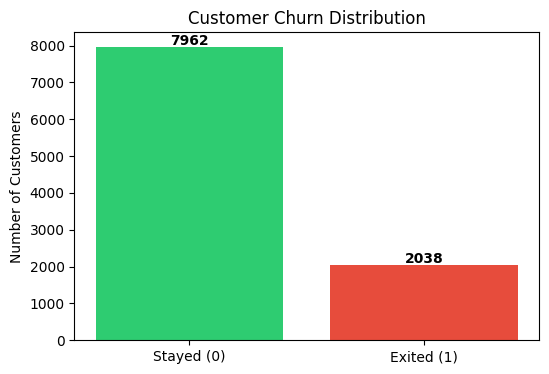

In [6]:
import matplotlib.pyplot as plt

counts = df['Exited'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(['Stayed (0)', 'Exited (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show()

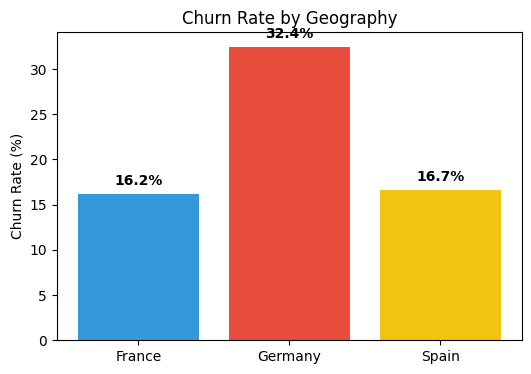

In [7]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(geo_churn.index, geo_churn.values, color=['#3498db', '#e74c3c', '#f1c40f'])
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(geo_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

C:\Users\arpan\AppData\Local\Temp\ipykernel_25340\4063804131.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100


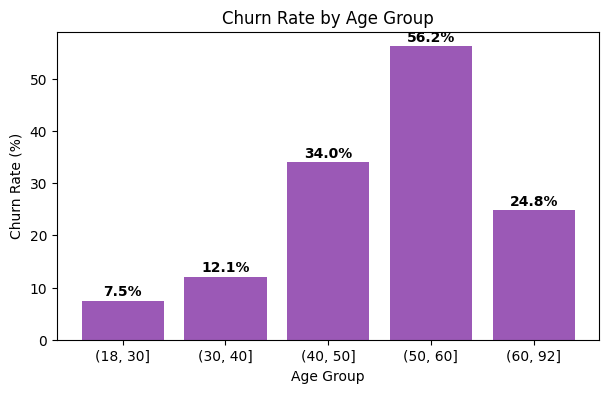

In [8]:
age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100

plt.figure(figsize=(7,4))
plt.bar(age_churn.index.astype(str), age_churn.values, color='#9b59b6')
plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Age Group')
for i, v in enumerate(age_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

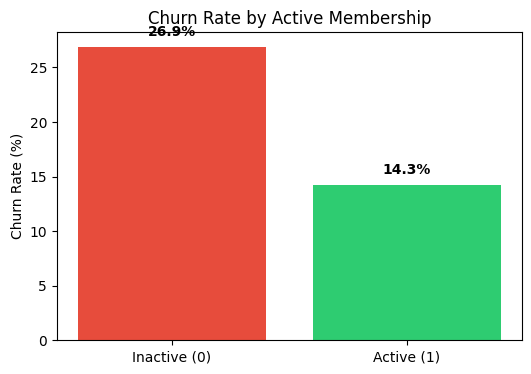

In [9]:
# Chart 4: Active Member
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(['Inactive (0)', 'Active (1)'], active_churn.values, color=['#e74c3c', '#2ecc71'])
plt.title('Churn Rate by Active Membership')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(active_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

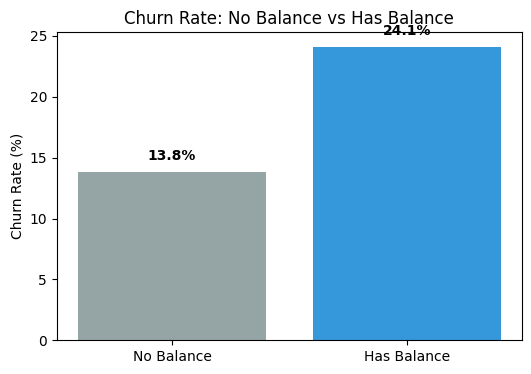

In [10]:
# Chart 5: Has Balance
balance_churn = df.groupby('HasBalance')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(['No Balance', 'Has Balance'], balance_churn.values, color=['#95a5a6', '#3498db'])
plt.title('Churn Rate: No Balance vs Has Balance')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(balance_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

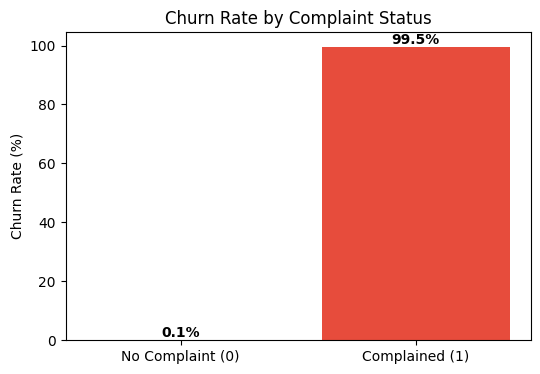

In [11]:
complain_churn = df.groupby('Complain')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(['No Complaint (0)', 'Complained (1)'], complain_churn.values, color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Complaint Status')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(complain_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()


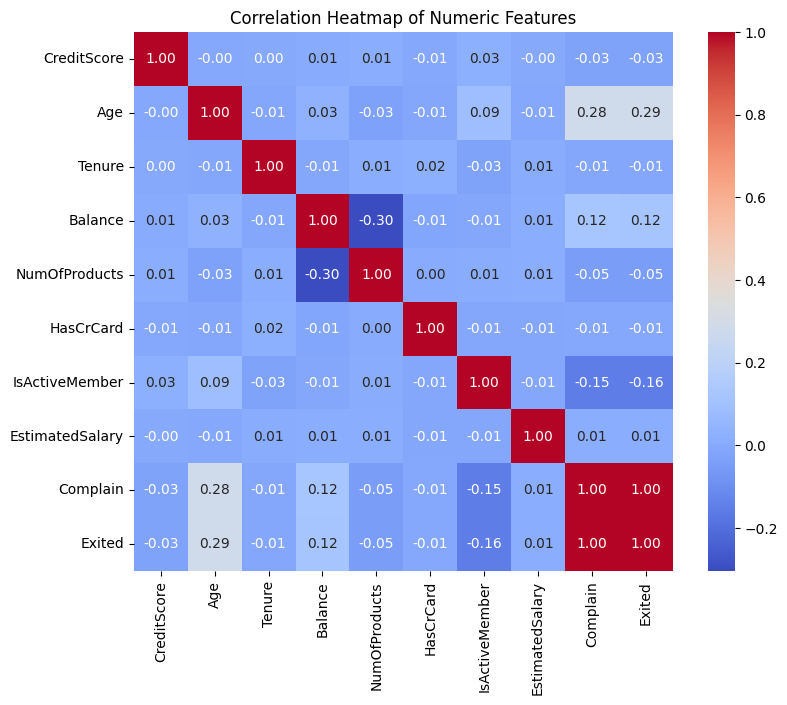

In [12]:
import seaborn as sns

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Exited']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Week 2: Creating Financial Forecasts

In [2]:
import pandas as pd
df = pd.read_csv("Customer-Churn-Records.csv")

In [4]:
import numpy as np

# Step A: average balance per tenure year
tenure_balance = df.groupby('Tenure')['Balance'].mean()
print(tenure_balance)

Tenure
0     79878.910630
1     78555.384222
2     76839.626469
3     77668.059881
4     74059.394065
5     76444.280860
6     74403.942637
7     75551.634426
8     77936.598254
9     76562.544014
10    73927.504000
Name: Balance, dtype: float64


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# X = tenure years (0-10), y = average balance
X = tenure_balance.index.values
y = tenure_balance.values

# Fit a straight line (degree=1 polynomial) through the points
coeffs = np.polyfit(X, y, deg=1)
slope, intercept = coeffs
print(f"Slope: {slope:.2f}  Intercept: {intercept:.2f}")

# Forecast tenure years 11 to 15
future_years = np.arange(11, 16)
forecast = slope * future_years + intercept
print(dict(zip(future_years, forecast)))

Slope: -348.42  Intercept: 78271.89
{np.int64(11): np.float64(74439.31007989071), np.int64(12): np.float64(74090.89388930172), np.int64(13): np.float64(73742.47769871271), np.int64(14): np.float64(73394.06150812372), np.int64(15): np.float64(73045.64531753471)}


In [6]:
for year, value in zip(future_years, forecast):
    print(f"Tenure {year}: ${value:,.2f}")

Tenure 11: $74,439.31
Tenure 12: $74,090.89
Tenure 13: $73,742.48
Tenure 14: $73,394.06
Tenure 15: $73,045.65


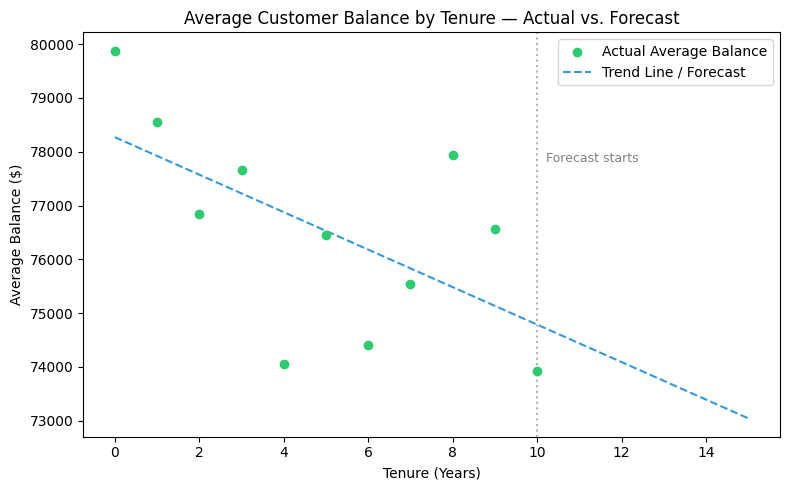

In [7]:
plt.figure(figsize=(8,5))

# Actual historical averages
plt.scatter(X, y, color='#2ecc71', label='Actual Average Balance', zorder=3)

# The fitted line + forecast, drawn across the full range (0 to 15)
all_years = np.arange(0, 16)
trend_line = slope * all_years + intercept
plt.plot(all_years, trend_line, color='#3498db', linestyle='--', label='Trend Line / Forecast')

# Mark where forecast begins
plt.axvline(x=10, color='gray', linestyle=':', alpha=0.6)
plt.text(10.2, plt.ylim()[1]*0.97, 'Forecast starts', fontsize=9, color='gray')

plt.title('Average Customer Balance by Tenure — Actual vs. Forecast')
plt.xlabel('Tenure (Years)')
plt.ylabel('Average Balance ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import r2_score

predicted = slope * X + intercept
r2 = r2_score(y, predicted)
print(f"R-squared: {r2:.3f}")

R-squared: 0.360
